In [1]:
print("all")


all


# from gtts import gTTS
# text = "This is multimodal AI, one of the most exciting areas in artificial intelligence, where models can understand and generate multiple types of data such as text, images, audio, and video, enabling powerful applications like image captioning, speech recognition, text-to-image generation, AI voice assistants, visual question answering, and intelligent agentic systems that can interact with the world in a much more human-like way."
# tts = gTTS(text=text, lang="en")
# tts.save("audio.mp3")


input   output
Text -> Text
Text -> Image
Image -> Text
Image -> Image(not required)
Text-> Audio
Audio -> Text
Audio -> Audio(not required)
text -> video 
video -> text


text to text model


95% times we are going to use text to text only


so this is imp
This OpenAI Model is PAID Anthropic Models are also PAID

if these are the PAID so everyone can not use it

so you want some free options

so lets me tell me some free options

reading the model from the openai or anthropic server using openai or claude key

our owm server how to config the model on our owm server

1. ollama
2. huggingface
git-->github(where we can host our code code is available in the repos) docker-->dockerhub(where we can keep our app in the form of images here is also we have a repo) huggingface-->huggingfacehub(over the huggingface hub you will have repo inside that repo model or dataset will be available) ollama-->ollama hub(here also we have severl model which we can download)

github--> code-->download(in your local system) dockerhub-->pull the image(in your local system) huggingface hub-->model, dataset (in local system) ollama hub or modelhub --> model (in your local system)

now lets suppose if you dont want take this overhead of configuring the model on your own server in that case you can use managed cloud platform here also you will have to be generate the API key this api key is going to cloud spcific api key

1. awzbedrock
2. azure AI cloud foundry
3. google vertex AI
4. github api enterprise version
we can access via langchain itself

server means your owns system

In [2]:
import os
OPENAI_API_KEY= os.getenv("OPENAI_API_KEY")
if OPENAI_API_KEY:
    os.environ["OPENAI_API_KEY"]=OPENAI_API_KEY


In [3]:

from langchain_openai import ChatOpenAI

/Users/ruchisehgal/Documents/Study Material/Gen AI and Agentic AI/Embedding/newenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:

from dotenv import load_dotenv
import os

load_dotenv()  # ← this reads your .env file
import os




In [7]:
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(model="gpt-5-nano")

In [8]:
message = llm.invoke("What is the capital of India?")
message


AIMessage(content="New Delhi. It's the seat of India's central government (located within the National Capital Territory of Delhi).", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 285, 'prompt_tokens': 13, 'total_tokens': 298, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DgYhzmttVoXbf71uQTQlschyGOcRY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e36c8-6d0d-75f0-9836-6d3703c38184-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 285, 'total_tokens': 298, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 256}})

In [9]:
message.content

"New Delhi. It's the seat of India's central government (located within the National Capital Territory of Delhi)."

In [10]:
#for gemini trial---skip it
from langchain_google_genai import ChatGoogleGenerativeAI
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


Text to Image

In [43]:
llm =ChatOpenAI(model = "gpt-5.4-mini")

In [44]:
kwargs= {"type": "image_generation","quality":"low"}
llm_with_tools=llm.bind_tools([kwargs])

In [45]:
ai_message = llm_with_tools.invoke("Draw a picture of a cute fuzzy cat with an umbrella")

In [46]:
import base64
from IPython.display import Image

In [47]:
image = next(
    item for item in ai_message.content_blocks if item["type"] == "image"
)

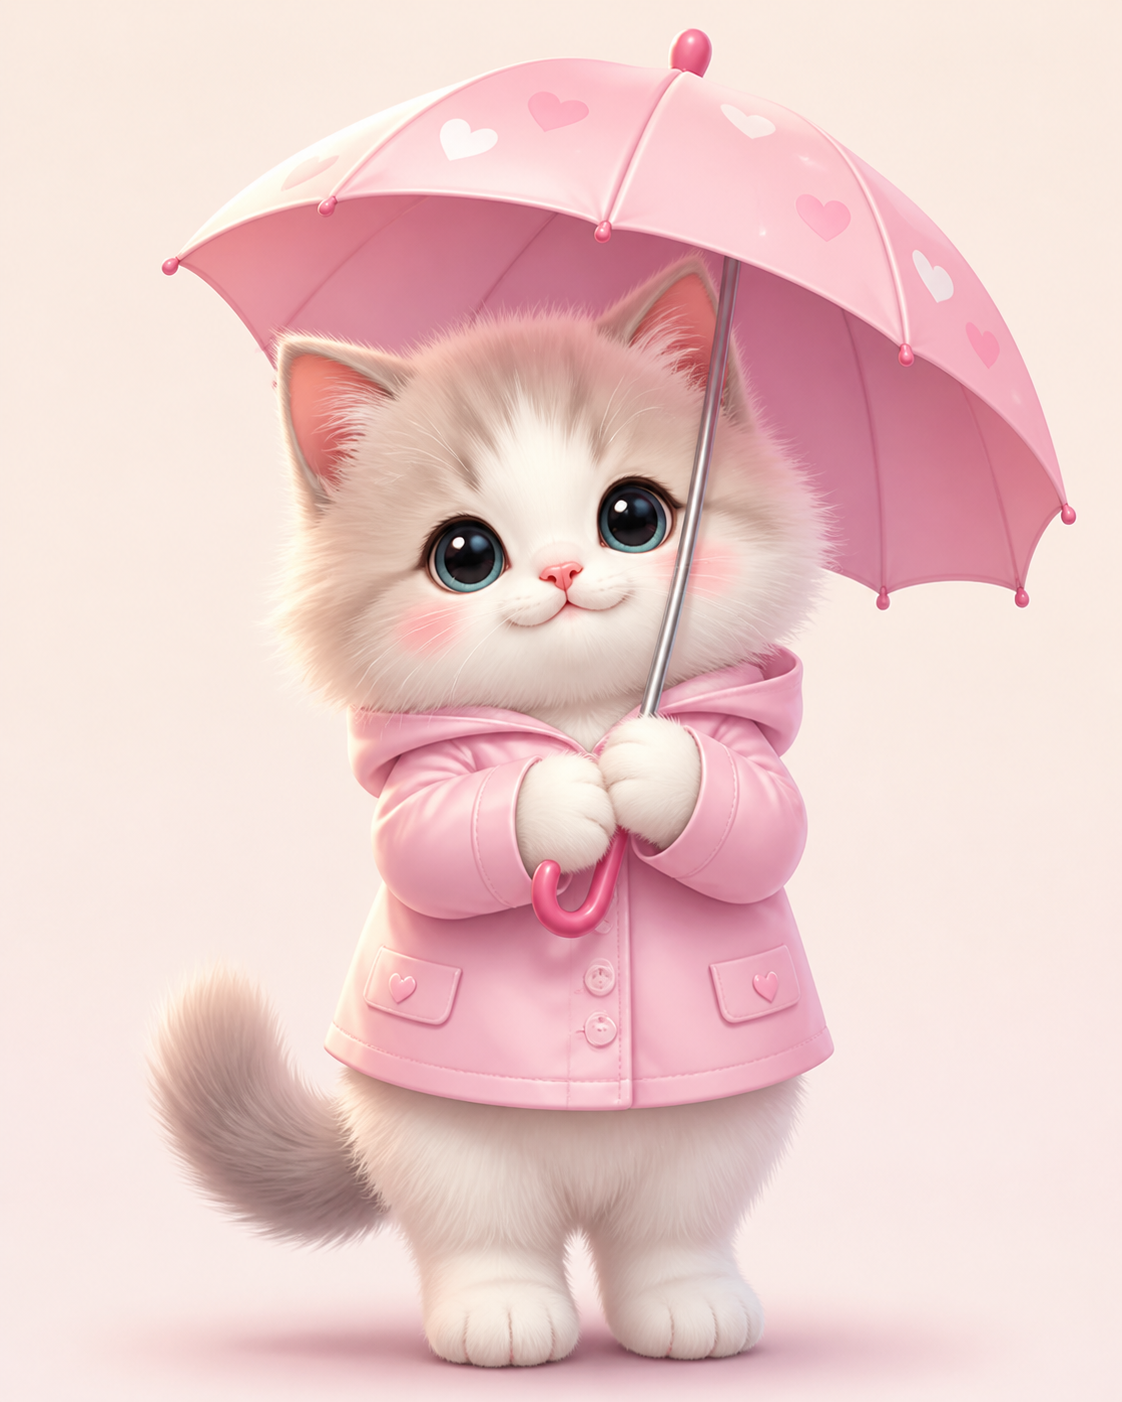

In [48]:
Image(base64.b64decode(image["base64"]), width=200)

IMAGE TO TEXT

OCR
RAG Pipeline

Model from OPENAI
OCR(optical character recognition)
to fetch a data from the images

it is cv based technique

ealier we were performing it using the CNN based model

Now we can perform OCR task using the Transformer based model(ViT)

These models plays a very imp role in MMRAG Pipeline

In [14]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [15]:
def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")

In [19]:
base64_image = encode_image(
    "/Users/ruchisehgal/Documents/Study Material/Gen AI and Agentic AI/Embedding/SOTA-Transformer-Embedding-methods/dogs.png"
)

In [ ]:
base64_image
#WILL GIVE LONG STRING

In [20]:
from langchain_core.messages import HumanMessage

In [21]:
message = HumanMessage(
    content=[
        {"type": "text", "text": "What is in this image?"},
        {
            "type": "image_url",
            "image_url": {
                "url": f"data:image/png;base64,{base64_image}"
            },
        },
    ]
)

In [22]:
response = llm.invoke([message])
print(response.content)

The image features a collection of cartoon-style dog characters, each with distinct features and expressions. They have exaggerated facial expressions with big eyes and playful smiles, showcasing a variety of dog breeds or types. The background is a solid color which emphasizes the colorful and lively appearance of the dogs.


In [23]:
message = HumanMessage(
    content=[
        {"type": "text", "text": "What is in this image?"},
        {
            "type": "image_url",
            "image_url": {
                "url": "https://www.coolutils.com/blog/wp-content/uploads/2025/06/jpg.png"
            },
        },
    ]
)

In [24]:
response = llm.invoke([message])
print(response.content)

The image features a graphic that includes the text "What Is a JPG File?" along with an icon that represents a JPG file. The icon typically shows a stylized representation of a document with an image on it, combined with the letters "JPG." The background has a gradient, likely transitioning from blue to pink.


The image appears to be a graphic that features a question, "What Is a JPG File?" along with an icon representing a JPG file. The icon likely includes imagery such as a document with a picture symbol and the letters "JPG" prominently displayed, all set against a colorful background.
The image features a playful illustration of six cartoon-style dogs. Each dog has a distinct expression, often with happy faces and their tongues out. The dogs vary in breed and fur textures, adding a fun and whimsical touch to the overall composition. The background is a solid color that contrasts nicely with the colorful dogs.

The image appears to be a graphic that features a question, "What Is a JPG File?" along with an icon representing a JPG file. The icon likely includes imagery such as a document with a picture symbol and the letters "JPG" prominently displayed, all set against a colorful background.

scratch --> limitation

So far we have seen OpenAI which is paid one Anthropic is also paid you can purchase their credits config the api key and run it via langchain Now lets access some free models text to text models text to image models image to text models are also possible

GROQ --? free access
Openrouter --? free access
Google(gemini api) --> here we have limited access of limited models
Huggingface Inferencing API
HuggingfaceHUB OllamaHUB

TEXT TO TEXT
--TRANSLATION

In [30]:
import os
GROQ_API_KEY = os.getenv ("GROQ_API_KEY")  # This will return None if the environment variable is not set


In [31]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()
import os


In [32]:
llm = ChatGroq(
    model="qwen/qwen3-32b")

In [33]:
messages = [
    (
        "system",
        "You are a helpful assistant that translates English to Hindi. Translate the user sentence.",
    ),
    ("human", "I love programming."),
]

In [34]:
ai_msg = llm.invoke(messages)

In [36]:
print(ai_msg.content)

<think>
Okay, the user wants to translate "I love programming." into Hindi. Let me start by breaking down the sentence.

"I love programming." is a simple sentence. The main components are "I", "love", and "programming". 

First, "I" in Hindi is "मैं". That's straightforward. 

Next, "love" can be translated as "प्यार करता हूँ" for a male speaker. If the user is female, it would be "प्यार करती हूँ". But since the user didn't specify, I'll default to the masculine form unless instructed otherwise.

Then, "programming" is the tricky part. In Hindi, "programming" is often transliterated as "प्रोग्रामिंग" since there's no direct translation. Alternatively, if a translation is needed, it might be "कम्प्यूटर प्रोग्रामिंग" to specify computer programming. But the context here is just "programming", so using the transliteration is more common in such cases.

Putting it all together: "मैं प्रोग्रामिंग का प्यार करता हूँ।" Wait, let me check the structure. The verb "love" in Hindi is "का प्यार कर

IMAGE TO text

In [37]:
llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct"
)

In [40]:
message = HumanMessage(
    content=[
        {
            "type": "text",
            "text": "Describe this image in detail."
        },
        {
            "type": "image_url",
            "image_url": {
                "url": "https://www.coolutils.com/blog/wp-content/uploads/2025/06/jpg.png"
            }
        }
    ]
)

In [41]:
response = llm.invoke([message])

In [42]:
response
print(response.content)

The image presents a concise and informative visual representation of the topic "What Is a JPG File?" The title, prominently displayed in large black text at the top, sets the stage for the content that follows. Below the title, a square icon with rounded corners takes center stage, featuring a gradient background that transitions from blue to purple, pink, orange, and yellow. This colorful icon is overlaid with a white outline of a document, complete with a folded corner and a mountain range graphic within it. The letters "JPG" are written in white text at the bottom of the document outline.

The background of the image is a clean and neutral white, providing a clear contrast to the vibrant colors of the icon. A subtle gray triangle is visible in the top-left and bottom-right corners, adding a touch of visual interest to the design. Overall, the image effectively communicates its message through a simple yet visually appealing combination of text and graphics. 

The image appears to b